
# Módulo 6 — Regularização implícita e robustez

> **Tema:** data augmentation (visão/texto/áudio), Mixup/CutMix, BatchNorm/LayerNorm e ruído no treino para robustez sob shift de distribuição.  
> **Objetivo didático:** entender como técnicas de regularização **implícita** melhoram generalização e estabilidade em cenários reais.

---

## Roteiro da aula

1. O que é regularização implícita e por que importa  
2. Data augmentation em visão, texto e áudio  
3. Mixup e CutMix: quando usar (e quando evitar)  
4. BatchNorm vs LayerNorm: efeito indireto na generalização  
5. Ruído no treino e robustez a covariate shift  
6. Estudo prático comparativo com métricas IID vs Shifted



## 0) Setup
Notebook totalmente executável em CPU (rápido), usando dataset `digits` do scikit-learn.


In [1]:

# =========================
# Setup e bibliotecas
# =========================
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu



## 1) Base de dados e cenário de *distribution shift*

Usaremos `digits` (imagens 8×8, 10 classes).  
Criaremos:
- **Validação IID** (mesma distribuição do treino)
- **Teste Shifted** (ruído + leve deslocamento), simulando mudança de domínio.


In [2]:

# =====================================
# Dados
# =====================================
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0    # [N, 8, 8] em [0,1]
y = digits.target.astype(np.int64)

# Split: train / val / test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=SEED, stratify=y_temp
)

def make_shifted_version(X_in, noise_std=0.25, max_shift=1):
    # Gera versão deslocada + ruidosa para simular covariate shift.
    Xs = X_in.copy()
    out = np.zeros_like(Xs)
    for i in range(len(Xs)):
        img = Xs[i]
        dx = np.random.randint(-max_shift, max_shift+1)
        dy = np.random.randint(-max_shift, max_shift+1)
        img = np.roll(img, shift=dx, axis=0)
        img = np.roll(img, shift=dy, axis=1)
        img = img + np.random.normal(0, noise_std, img.shape).astype(np.float32)
        img = np.clip(img, 0, 1)
        out[i] = img
    return out

X_test_shift = make_shifted_version(X_test, noise_std=0.30, max_shift=1)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape, "Shifted test:", X_test_shift.shape)


Train: (1149, 8, 8) Val: (288, 8, 8) Test: (360, 8, 8) Shifted test: (360, 8, 8)


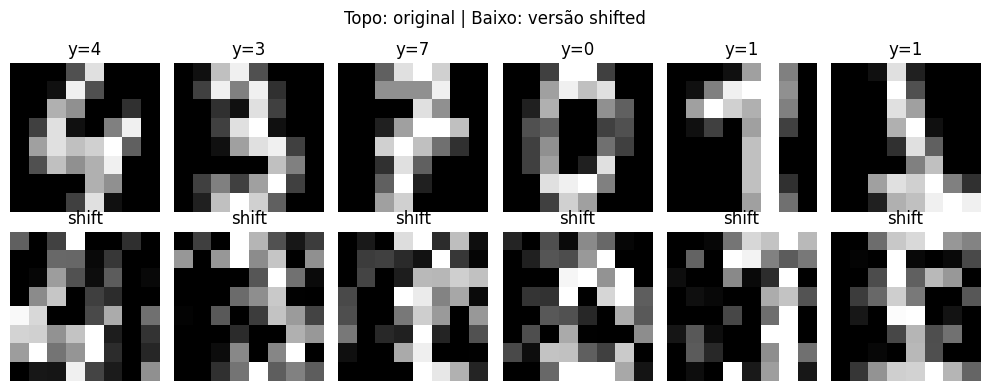

In [3]:

# Visualização rápida IID vs Shifted
idxs = np.random.choice(len(X_test), size=6, replace=False)

plt.figure(figsize=(10,4))
for i, idx in enumerate(idxs):
    plt.subplot(2,6,i+1)
    plt.imshow(X_test[idx], cmap="gray")
    plt.axis("off")
    plt.title(f"y={y_test[idx]}")

    plt.subplot(2,6,6+i+1)
    plt.imshow(X_test_shift[idx], cmap="gray")
    plt.axis("off")
    plt.title("shift")
plt.suptitle("Topo: original | Baixo: versão shifted")
plt.tight_layout()
plt.show()



## 2) Data augmentation em diferentes modalidades (didático)

### 2.1 Visão
Exemplos comuns:
- flip/crop/rotação/ruído/color jitter
- randaugment, autoaugment, cutout

### 2.2 Texto
Exemplos:
- deleção de palavras
- substituição/swap de tokens
- back-translation

### 2.3 Áudio
Exemplos:
- time shift
- adição de ruído
- SpecAugment (time/frequency masking)


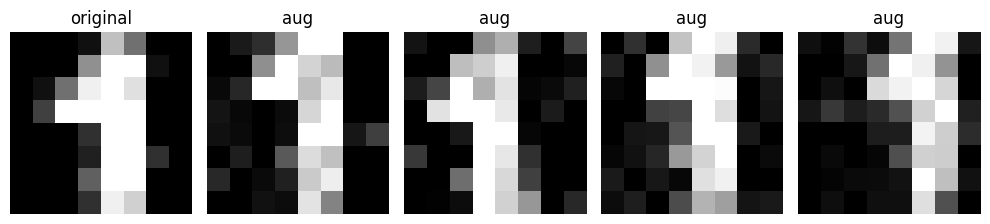

In [4]:

# =====================================
# 2.1 Visão: augment simples no digits
# =====================================
def aug_image(img):
    out = img.copy()
    dx = np.random.randint(-1, 2)
    dy = np.random.randint(-1, 2)
    out = np.roll(out, dx, axis=0)
    out = np.roll(out, dy, axis=1)
    out = out + np.random.normal(0, 0.15, out.shape).astype(np.float32)
    return np.clip(out, 0, 1)

sample = X_train[np.random.randint(0, len(X_train))]
aug_samples = [aug_image(sample) for _ in range(4)]

plt.figure(figsize=(10,2.8))
plt.subplot(1,5,1)
plt.imshow(sample, cmap="gray")
plt.title("original")
plt.axis("off")

for i, a in enumerate(aug_samples, start=2):
    plt.subplot(1,5,i)
    plt.imshow(a, cmap="gray")
    plt.title("aug")
    plt.axis("off")
plt.tight_layout()
plt.show()


In [5]:

# =====================================
# 2.2 Texto: toy augmentation
# =====================================
def random_deletion(tokens, p=0.2):
    if len(tokens) == 1:
        return tokens
    kept = [t for t in tokens if random.random() > p]
    return kept if len(kept) > 0 else [random.choice(tokens)]

def random_swap(tokens, n_swaps=2):
    tokens = tokens.copy()
    for _ in range(n_swaps):
        if len(tokens) < 2:
            break
        i, j = random.sample(range(len(tokens)), 2)
        tokens[i], tokens[j] = tokens[j], tokens[i]
    return tokens

text = "modelos profundos podem superajustar quando há poucos dados de treino"
tokens = text.split()

print("Original :", " ".join(tokens))
print("Deletion :", " ".join(random_deletion(tokens, p=0.25)))
print("Swap     :", " ".join(random_swap(tokens, n_swaps=3)))


Original : modelos profundos podem superajustar quando há poucos dados de treino
Deletion : modelos podem quando há poucos de
Swap     : de profundos podem modelos quando há poucos dados treino superajustar


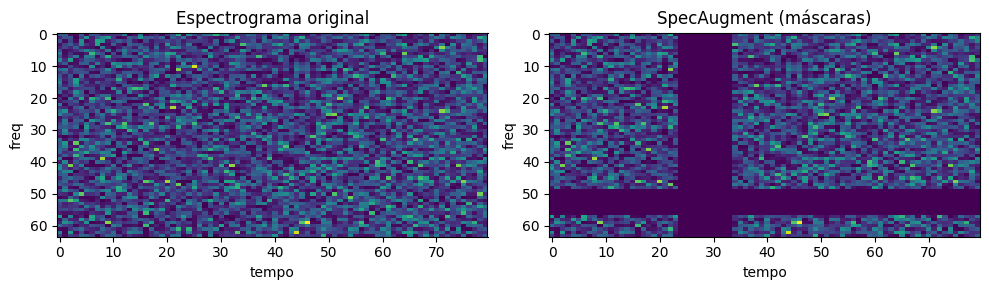

In [6]:

# =====================================
# 2.3 Áudio: toy SpecAugment em espectrograma sintético
# =====================================
spec = np.abs(np.random.randn(64, 80)).astype(np.float32)  # [freq, time]

def spec_augment(s, freq_mask=10, time_mask=12):
    out = s.copy()
    f0 = np.random.randint(0, max(1, s.shape[0]-freq_mask))
    out[f0:f0+freq_mask, :] = 0
    t0 = np.random.randint(0, max(1, s.shape[1]-time_mask))
    out[:, t0:t0+time_mask] = 0
    return out

spec_aug = spec_augment(spec, freq_mask=8, time_mask=10)

plt.figure(figsize=(10,3))
plt.subplot(1,2,1)
plt.imshow(spec, aspect="auto")
plt.title("Espectrograma original")
plt.xlabel("tempo")
plt.ylabel("freq")

plt.subplot(1,2,2)
plt.imshow(spec_aug, aspect="auto")
plt.title("SpecAugment (máscaras)")
plt.xlabel("tempo")
plt.ylabel("freq")
plt.tight_layout()
plt.show()



## 3) Dataset para treino em PyTorch (flatten para MLP)

Vamos usar vetores de 64 features (8×8), mantendo o foco em regularização/otimização.


In [7]:

# =====================================
# Preparação dos tensores
# =====================================
X_train_f = X_train.reshape(len(X_train), -1)
X_val_f = X_val.reshape(len(X_val), -1)
X_test_f = X_test.reshape(len(X_test), -1)
X_test_shift_f = X_test_shift.reshape(len(X_test_shift), -1)

X_train_t = torch.tensor(X_train_f, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_f, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_f, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)
X_test_shift_t = torch.tensor(X_test_shift_f, dtype=torch.float32)
y_test_shift_t = torch.tensor(y_test, dtype=torch.long)

def make_loaders(batch_size=64):
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)
    test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=256, shuffle=False)
    test_shift_loader = DataLoader(TensorDataset(X_test_shift_t, y_test_shift_t), batch_size=256, shuffle=False)
    return train_loader, val_loader, test_loader, test_shift_loader

train_loader, val_loader, test_loader, test_shift_loader = make_loaders(64)
print("Loaders prontos.")


Loaders prontos.



## 4) BatchNorm e LayerNorm no mesmo backbone

Vamos comparar três versões:
- sem normalização
- BatchNorm
- LayerNorm


In [ ]:
# Experimento Visual: Anatomia do Batch Normalization
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from ipywidgets import interact, IntSlider, ToggleButtons

def visualize_bn_effect(depth=20, use_bn=False, activation_type='Tanh'):
    # 1. Configuração: Uma rede PROFUNDA (Deep)
    # Redes profundas sofrem mais com a mudança de distribuição

    class DeepNet(nn.Module):
        def __init__(self, depth, use_bn, activation):
            super().__init__()
            self.layers = nn.ModuleList()
            self.use_bn = use_bn

            # Construindo camadas
            for i in range(depth):
                self.layers.append(nn.Linear(50, 50))
                if self.use_bn:
                    self.layers.append(nn.BatchNorm1d(50))
                self.layers.append(activation)

        def forward(self, x):
            # Vamos salvar a saída de cada camada para visualizar
            activations = []
            out = x
            for layer in self.layers:
                out = layer(out)
                # Salvar apenas após a ativação (não BN ou Linear)
                if isinstance(layer, (nn.ReLU, nn.Tanh, nn.Sigmoid)):
                    activations.append(out.detach().flatten().numpy())
            return activations

    # 2. Inicialização Ruim (Desafio para a rede)
    # Pesos altos normalmente fariam a rede explodir ou saturar sem BN
    def init_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0, std=1.0) # std alto!

    # Escolha da Ativação
    act_dict = {'ReLU': nn.ReLU(), 'Tanh': nn.Tanh(), 'Sigmoid': nn.Sigmoid()}
    activation = act_dict[activation_type]

    model = DeepNet(depth, use_bn, activation)
    model.apply(init_weights)

    # 3. Passar Dados (Forward Pass)
    # Simulamos um batch de dados passando pela rede
    torch.manual_seed(42)
    dummy_input = torch.randn(256, 50) # Batch de 256

    with torch.no_grad():
        if use_bn:
            model.train() # BN precisa estar em modo treino para calcular estatísticas
        activations = model(dummy_input)

    # 4. Visualização (Heatmap das Distribuições)
    fig, ax = plt.subplots(figsize=(12, 6))

    # Preparar dados para Boxplot/Violinplot
    # Queremos ver a distribuição da camada 1, camada 5, camada 10...

    data_to_plot = []
    labels = []

    # Selecionar algumas camadas para não poluir
    indices = np.linspace(0, len(activations)-1, 10).astype(int)

    for i in indices:
        data_to_plot.append(activations[i])
        labels.append(f"L{i+1}")

    # Plotar Violin Plot (mostra a densidade)
    parts = ax.violinplot(data_to_plot, showmeans=False, showmedians=True)

    # Estilização
    for pc in parts['bodies']:
        pc.set_facecolor('#3498db' if use_bn else '#e74c3c')
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)

    ax.set_xticks(np.arange(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_title(f"Distribuição das Ativações ({'COM' if use_bn else 'SEM'} Batch Norm)\nAtivação: {activation_type} | Profundidade: {depth}", fontsize=14)
    ax.set_xlabel("Profundidade da Rede (Camadas)")
    ax.set_ylabel("Valor da Ativação")

    # Linhas de limite para Tanh/Sigmoid
    if activation_type == 'Tanh':
        ax.set_ylim(-1.5, 1.5)
        ax.axhline(1, color='gray', linestyle='--')
        ax.axhline(-1, color='gray', linestyle='--')
    elif activation_type == 'Sigmoid':
        ax.set_ylim(-0.2, 1.2)
    else: # ReLU
        ax.set_ylim(-1, 5)

    plt.grid(True, alpha=0.3)

    # Texto Explicativo
    if not use_bn:
        if activation_type == 'ReLU':
            msg = "Sintoma: Explosão ou Colapso! A distribuição muda de escala drasticamente."
        else:
            msg = "Sintoma: Saturação! Os valores acumulam em -1 e 1 (Gradiente morre)."
        plt.figtext(0.5, 0.01, msg, ha="center", fontsize=12, bbox={"facecolor":"red", "alpha":0.1, "pad":5})
    else:
        plt.figtext(0.5, 0.01, "Resultado: Estabilidade! A distribuição se mantém centrada e saudável.", ha="center", fontsize=12, bbox={"facecolor":"blue", "alpha":0.1, "pad":5})

    plt.show()

print("O Batch Norm força os dados a ficarem 'comportados' (Média 0, Desvio 1).")
print("Sem ele, em redes profundas, o sinal se perde (fica muito grande ou muito pequeno).")

interact(visualize_bn_effect,
         depth=IntSlider(min=2, max=50, step=5, value=20, description='Profundidade'),
         use_bn=ToggleButtons(options=[False, True], description='Batch Norm?'),
         activation_type=ToggleButtons(options=['Tanh', 'Sigmoid', 'ReLU'], value='Tanh'));

O Batch Norm força os dados a ficarem 'comportados' (Média 0, Desvio 1).
Sem ele, em redes profundas, o sinal se perde (fica muito grande ou muito pequeno).


interactive(children=(IntSlider(value=20, description='Profundidade', max=50, min=2, step=5), ToggleButtons(de…

Este experimento visualiza a densidade das ativações (o histograma dos valores) passando pelas camadas da rede.

* Sem BN: Você verá as ativações "morrendo" (ficando presas no zero) ou "saturando" (presas nos extremos) conforme aprofundamos na rede. A distribuição colapsa.

* Com BN: A distribuição se mantém saudável (centrada e larga) da primeira à última camada, permitindo que a rede aprenda rápido.

In [14]:
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "--break-system-packages", "-q"])

0

In [9]:

class MLPNorm(nn.Module):
    def __init__(self, norm_type="none", p_drop=0.1):
        super().__init__()

        def norm_layer(dim):
            if norm_type == "batch":
                return nn.BatchNorm1d(dim)
            elif norm_type == "layer":
                return nn.LayerNorm(dim)
            else:
                return nn.Identity()

        self.fc1 = nn.Linear(64, 128)
        self.n1 = norm_layer(128)
        self.fc2 = nn.Linear(128, 128)
        self.n2 = norm_layer(128)
        self.fc3 = nn.Linear(128, 10)
        self.drop = nn.Dropout(p_drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.n1(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.n2(x)
        x = F.relu(x)
        x = self.drop(x)

        x = self.fc3(x)
        return x


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, ToggleButtons

# Experimento 2: Estabilidade de Ativação (BN vs LN)
# Mostra por que Batch Norm falha com batches pequenos e por que Layer Norm é estável.

def visualize_normalization_dynamics(batch_size=4, norm_type='BatchNorm'):
    # 1. Criar dados de ativação simulados (Feature Map)
    # Suponha features vindas de uma convolução: (Batch, Channels, Height, Width)
    # Mas com "Internal Covariate Shift" (Média e Desvio variando muito)
    np.random.seed(42)
    n_channels = 20

    # Simula ativações "selvagens" antes da normalização (Shifted & Scaled)
    # Cada canal tem uma média/std diferente e "ruim"
    means = np.random.uniform(-5, 5, n_channels)
    stds = np.random.uniform(0.5, 3, n_channels)

    # Dados de entrada (Batch, Canais)
    # Em BN: Normalizamos ao longo do eixo BATCH (vertical)
    # Em LN: Normalizamos ao longo do eixo CANAIS (horizontal)
    data = np.zeros((batch_size, n_channels))
    for c in range(n_channels):
        data[:, c] = np.random.normal(means[c], stds[c], batch_size)

    # 2. Aplicar Normalização Manualmente para visualizar
    data_norm = np.zeros_like(data)

    if norm_type == 'Sem Normalização':
        data_norm = data
        stats_msg = "Ativações explodindo e deslocadas."

    elif norm_type == 'BatchNorm':
        # Calcula média/std por CANAL (usando todo o batch)
        # Se batch for pequeno (ex: 2), a média é ruidosa!
        batch_mean = np.mean(data, axis=0)
        batch_std = np.std(data, axis=0) + 1e-5
        data_norm = (data - batch_mean) / batch_std
        stats_msg = f"BN usa estatística do Batch (N={batch_size}). Instável se N for pequeno."

    elif norm_type == 'LayerNorm':
        # Calcula média/std por AMOSTRA (usando todos os canais)
        # Independente do batch size
        sample_mean = np.mean(data, axis=1, keepdims=True)
        sample_std = np.std(data, axis=1, keepdims=True) + 1e-5
        data_norm = (data - sample_mean) / sample_std
        stats_msg = "LN normaliza cada amostra individualmente. Estável sempre."

    # 3. Visualização (Heatmaps)
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Antes da Norm
    sns.heatmap(data, ax=ax[0], cmap='coolwarm', center=0, vmin=-5, vmax=5, cbar=False)
    ax[0].set_title(f"Input Bruto (Batch={batch_size})\n(Note as cores extremas/bias)")
    ax[0].set_ylabel("Amostras do Batch")
    ax[0].set_xlabel("Canais / Features")

    # Depois da Norm
    sns.heatmap(data_norm, ax=ax[1], cmap='coolwarm', center=0, vmin=-3, vmax=3)
    ax[1].set_title(f"Pós-{norm_type}\n(Note a uniformidade)")
    ax[1].set_xlabel("Canais / Features")

    plt.suptitle(f"Dinâmica: {stats_msg}", y=1.05, fontsize=12)
    plt.show()

import seaborn as sns
print("Veja a diferença crítica: BatchNorm 'limpa' verticalmente, LayerNorm horizontalmente.")
print("Teste Batch Size = 2. O BatchNorm falha (estatística pobre). O LayerNorm segue perfeito.")

interact(visualize_normalization_dynamics,
         norm_type=ToggleButtons(options=['Sem Normalização', 'BatchNorm', 'LayerNorm']),
         batch_size=IntSlider(min=2, max=64, step=2, value=4, description='Batch Size'));

Veja a diferença crítica: BatchNorm 'limpa' verticalmente, LayerNorm horizontalmente.
Teste Batch Size = 2. O BatchNorm falha (estatística pobre). O LayerNorm segue perfeito.


interactive(children=(IntSlider(value=4, description='Batch Size', max=64, min=2, step=2), ToggleButtons(descr…


## 5) Mixup e CutMix (versão para vetores)

### Mixup
\[
$\tilde{x}=\lambda x_i + (1-\lambda)x_j,\quad
\tilde{y}=\lambda y_i + (1-\lambda)y_j$
\]

### CutMix (aqui em vetor)
Troca um segmento de features entre exemplos e ajusta peso do loss.

> Em imagens reais, CutMix costuma trocar regiões espaciais (retângulos).


In [17]:

def mixup_data(x, y, alpha=0.4):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    index = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def cutmix_vector_data(x, y, alpha=1.0):
    if alpha <= 0:
        return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    bs, d = x.size()
    index = torch.randperm(bs, device=x.device)

    cut_ratio = np.sqrt(1.0 - lam)
    cut_len = int(d * cut_ratio)
    cut_len = max(1, min(cut_len, d))

    cx = np.random.randint(0, d)
    x1 = max(0, cx - cut_len // 2)
    x2 = min(d, cx + cut_len // 2)

    x_cut = x.clone()
    x_cut[:, x1:x2] = x[index, x1:x2]

    lam_adjusted = 1.0 - (x2 - x1) / d
    y_a, y_b = y, y[index]
    return x_cut, y_a, y_b, lam_adjusted

def mix_criterion(logits, y_a, y_b, lam):
    return lam * F.cross_entropy(logits, y_a) + (1 - lam) * F.cross_entropy(logits, y_b)


Em visão computacional moderna (YOLO, ViT), usamos CutMix (recortar e colar pedaços) porque o Mixup tradicional (transparência) pode criar imagens "fantasmas" não naturais.

Este widget simula as duas técnicas em tempo real com imagens dummy, mostrando como os Labels (Rótulos) devem ser suavizados proporcionalmente.

In [ ]:
# Experimento 1: Visualizador de Mixup e CutMix (Anatomia da Augmentation)
import torch
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, ToggleButtons

def visualize_advanced_augmentations(aug_type='Mixup', alpha=1.0, lam_fixo=None):
    # 1. Criar duas "Imagens" sintéticas (Padrões 2D)
    # Imagem A: Padrão de Xadrez (Representa Classe 0)
    img_a = np.zeros((32, 32))
    img_a[::4, ::4] = 1.0
    label_a = np.array([1.0, 0.0]) # Classe 0 (One-hot)

    # Imagem B: Padrão de Círculo (Representa Classe 1)
    y, x = np.ogrid[:32, :32]
    mask = (x - 16)**2 + (y - 16)**2 <= 10**2
    img_b = np.zeros((32, 32))
    img_b[mask] = 1.0
    label_b = np.array([0.0, 1.0]) # Classe 1 (One-hot)

    # 2. Amostrar Lambda da distribuição Beta
    if lam_fixo is None:
        if alpha > 0:
            lam = np.random.beta(alpha, alpha)
        else:
            lam = 1.0
    else:
        lam = lam_fixo # Para controle manual no slider

    # 3. Aplicar a Augmentation
    img_aug = np.zeros_like(img_a)

    if aug_type == 'Mixup':
        # Mistura linear de pixels e labels
        img_aug = lam * img_a + (1 - lam) * img_b
        label_aug = lam * label_a + (1 - lam) * label_b
        title_text = f"Mixup (Blend): {lam:.2f} * A + {1-lam:.2f} * B"

    elif aug_type == 'CutMix':
        # Recorte e colagem
        # Definir caixa delimitadora (Bounding Box) baseada em lambda
        # area_ratio = 1 - lambda
        W, H = 32, 32
        cut_rat = np.sqrt(1. - lam)
        cut_w = int(W * cut_rat)
        cut_h = int(H * cut_rat)

        # Centro aleatório
        cx = np.random.randint(W)
        cy = np.random.randint(H)

        bbx1 = np.clip(cx - cut_w // 2, 0, W)
        bby1 = np.clip(cy - cut_h // 2, 0, H)
        bbx2 = np.clip(cx + cut_w // 2, 0, W)
        bby2 = np.clip(cy + cut_h // 2, 0, H)

        img_aug = img_a.copy()
        img_aug[bbx1:bbx2, bby1:bby2] = img_b[bbx1:bbx2, bby1:bby2]

        # Ajustar lambda real baseado na área do pixel
        lam_adjust = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
        label_aug = lam_adjust * label_a + (1 - lam_adjust) * label_b
        title_text = f"CutMix (Patch): Área A={lam_adjust:.2f}, Área B={1-lam_adjust:.2f}"

    # 4. Visualização
    fig, ax = plt.subplots(1, 4, figsize=(16, 4))

    ax[0].imshow(img_a, cmap='magma', vmin=0, vmax=1)
    ax[0].set_title("Input A (Classe 0)")
    ax[0].axis('off')

    ax[1].imshow(img_b, cmap='viridis', vmin=0, vmax=1)
    ax[1].set_title("Input B (Classe 1)")
    ax[1].axis('off')

    ax[2].imshow(img_aug, cmap='inferno', vmin=0, vmax=1)
    ax[2].set_title(f"Resultado: {aug_type}")
    ax[2].axis('off')

    # Gráfico de Barras do Label Suavizado
    ax[3].bar(['Classe 0', 'Classe 1'], label_aug, color=['orange', 'teal'])
    ax[3].set_ylim(0, 1.1)
    ax[3].set_title("Novo Rótulo (Soft Label)")
    ax[3].text(0, label_aug[0]+0.05, f"{label_aug[0]:.2f}", ha='center')
    ax[3].text(1, label_aug[1]+0.05, f"{label_aug[1]:.2f}", ha='center')

    plt.suptitle(title_text, fontsize=14)
    plt.show()

print("CutMix é SOTA em Transformers/CNNs modernos.")
print("Observe como o rótulo (gráfico de barras) muda proporcionalmente à mistura.")
interact(visualize_advanced_augmentations,
         aug_type=ToggleButtons(options=['Mixup', 'CutMix']),
         alpha=FloatSlider(min=0.1, max=5.0, step=0.1, value=1.0, description='Alpha (Dist Beta)'),
         lam_fixo=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.6, description='Lambda (Mistura)'));

CutMix é SOTA em Transformers/CNNs modernos.
Observe como o rótulo (gráfico de barras) muda proporcionalmente à mistura.


interactive(children=(ToggleButtons(description='aug_type', options=('Mixup', 'CutMix'), value='Mixup'), Float…


## 6) Treino e avaliação (IID e Shifted)

Opções de treino:
- `augmentation='none'`
- `augmentation='noise'` (ruído gaussiano no input)
- `augmentation='mixup'`
- `augmentation='cutmix'`


**Experimento: O Dataset Infinito**
Este código gera uma imagem padrão e permite aplicar transformações em tempo real.

Mais importante: ele tem um modo "Batch View", que mostra como a rede vê esse único dado ao longo de várias épocas (cada vez diferente).

In [ ]:
# Experimento Visual: Data Augmentation Playground
# Mostra como transformar UMA imagem em MILHARES de variações de treino.

import torch
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, ToggleButtons
import torchvision.transforms.functional as TF
from PIL import Image, ImageDraw, ImageFont

def visualize_augmentation(rotation=0, translate=0, scale=1.0, noise=0.0, cutout_size=0, view_mode='Single'):
    # 1. Criar uma Imagem Sintética "Rica" (Para ver bem os efeitos)
    # Criamos um padrão com texto e formas geométricas para notar distorções
    W, H = 200, 200
    img_pil = Image.new('RGB', (W, H), color=(30, 30, 30))
    draw = ImageDraw.Draw(img_pil)

    # Desenhar formas
    draw.rectangle([50, 50, 150, 150], outline=(0, 255, 255), width=5) # Quadrado Ciano
    draw.ellipse([70, 70, 130, 130], fill=(255, 0, 128)) # Círculo Rosa
    draw.line([0, 0, 200, 200], fill=(255, 255, 0), width=3) # Linha Amarela

    # Texto (Crucial para ver espelhamento/rotação)
    try:
        # Tenta fonte padrão, se não tiver usa padrão bitmap
        # font = ImageFont.truetype("arial.ttf", 24)
        # draw.text((60, 160), "DL 2024", font=font, fill=(255, 255, 255))
        draw.text((60, 160), "DL 2024", fill=(255, 255, 255))
    except:
        pass

    # Converter para Tensor (C, H, W) e normalizar para [0, 1]
    img_tensor = TF.to_tensor(img_pil)

    # 2. Função de Aplicação de Augmentation
    def apply_transforms(img, r, t, s, n, c):
        # A. Transformações Geométricas (Affine)
        # Random Rotation, Translation, Scale
        # No PyTorch usamos affine para fazer tudo junto
        angle = float(torch.empty(1).uniform_(-r, r).item()) if r > 0 else 0
        trans_x = float(torch.empty(1).uniform_(-t, t).item()) * W if t > 0 else 0
        trans_y = float(torch.empty(1).uniform_(-t, t).item()) * H if t > 0 else 0
        scale_factor = float(torch.empty(1).uniform_(1-s, 1+s).item()) if s > 0 else 1.0

        img_aug = TF.affine(img, angle=angle, translate=[trans_x, trans_y], scale=scale_factor, shear=0)

        # B. Ruído (Pixel-level)
        if n > 0:
            noise_tensor = torch.randn_like(img_aug) * n
            img_aug = torch.clamp(img_aug + noise_tensor, 0, 1)

        # C. Cutout (Random Erasing) - Muito usado em SOTA
        if c > 0:
            # Apaga um quadrado aleatório
            cx = int(torch.randint(0, W, (1,)).item())
            cy = int(torch.randint(0, H, (1,)).item())
            half = int(c * W / 2)

            x1 = max(0, cx - half)
            y1 = max(0, cy - half)
            x2 = min(W, cx + half)
            y2 = min(H, cy + half)

            img_aug[:, y1:y2, x1:x2] = 0.0 # Preenche com preto

        return img_aug

    # 3. Visualização
    if view_mode == 'Single':
        # Mostrar Original vs 1 Augmentada
        img_aug = apply_transforms(img_tensor, rotation, translate, scale - 1.0, noise, cutout_size) # Scale slider is 1.0 based

        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img_tensor.permute(1, 2, 0))
        ax[0].set_title("Original (O que você coletou)")
        ax[0].axis('off')

        ax[1].imshow(img_aug.permute(1, 2, 0))
        ax[1].set_title("Augmented (O que a rede vê)")
        ax[1].axis('off')

    else: # Batch View
        # Mostrar como a rede vê essa imagem ao longo de 8 épocas
        fig, axes = plt.subplots(2, 4, figsize=(16, 8))
        axes = axes.flatten()

        for i in range(8):
            # Gera uma variação aleatória dentro dos parâmetros definidos
            img_aug = apply_transforms(img_tensor, rotation, translate, scale - 1.0, noise, cutout_size)
            axes[i].imshow(img_aug.permute(1, 2, 0))
            axes[i].set_title(f"Época {i+1}")
            axes[i].axis('off')

        plt.suptitle(f"O Dataset Infinito: Variações da MESMA imagem", fontsize=16)

    plt.show()

print("Aumente os sliders para criar novos dados.")
print("Use o modo 'Batch View' para ver a diversidade gerada a partir de uma única imagem.")

interact(visualize_augmentation,
         rotation=FloatSlider(min=0, max=180, step=5, value=15, description='Rotação (graus)'),
         translate=FloatSlider(min=0, max=0.5, step=0.05, value=0.1, description='Translação (%)'),
         scale=FloatSlider(min=1.0, max=2.0, step=0.1, value=1.0, description='Zoom Max'),
         noise=FloatSlider(min=0.0, max=0.5, step=0.05, value=0.0, description='Ruído'),
         cutout_size=FloatSlider(min=0.0, max=0.5, step=0.05, value=0.0, description='Cutout Size'),
         view_mode=ToggleButtons(options=['Single', 'Batch View'], description='Modo'));

Aumente os sliders para criar novos dados.
Use o modo 'Batch View' para ver a diversidade gerada a partir de uma única imagem.


interactive(children=(FloatSlider(value=15.0, description='Rotação (graus)', max=180.0, step=5.0), FloatSlider…

1. **O Poder do "Grátis":**
* Vocês coletaram apenas 1 imagem, mas ajustando a rotação e o zoom, a rede neural treinou em 8 imagens diferentes. Se treinarem por 100 épocas, ela verá 100 versões diferentes.

2. **Cutout (O Quadrado Preto):**
* Mova o slider Cutout Size. Um quadrado preto vai aparecer aleatoriamente.
* Conceito: Isso obriga a rede a não depender de apenas uma característica. Se o quadrado tapar o "círculo rosa", a rede tem que reconhecer a imagem pelo "quadrado ciano". Isso cria robustez extrema (SOTA em reconhecimento de objetos).

3. **Segurança (Safety):**
* Aumente todos os sliders ao máximo. A imagem fica irreconhecível?
* Lição: Se você (humano) não consegue reconhecer, a rede também não vai. Cuidado com Augmentation destrutiva!

In [20]:

def evaluate(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = logits.argmax(dim=1).cpu().numpy()
            y_true.append(yb.numpy())
            y_pred.append(pred)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return {"acc": acc, "f1_macro": f1}

def train_model(
    norm_type="none",
    augmentation="none",   # none | noise | mixup | cutmix
    noise_std=0.15,
    alpha=0.4,
    epochs=35,
    lr=1e-3,
    batch_size=64,
):
    torch.manual_seed(SEED)
    model = MLPNorm(norm_type=norm_type, p_drop=0.1).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    train_loader, val_loader, test_loader, test_shift_loader = make_loaders(batch_size)
    history = {"train_loss": [], "val_acc": [], "val_f1": []}

    for epoch in range(epochs):
        model.train()
        losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()

            if augmentation == "noise":
                xb_aug = xb + noise_std * torch.randn_like(xb)
                xb_aug = torch.clamp(xb_aug, 0.0, 1.0)
                logits = model(xb_aug)
                loss = F.cross_entropy(logits, yb)

            elif augmentation == "mixup":
                x_mix, y_a, y_b, lam = mixup_data(xb, yb, alpha=alpha)
                logits = model(x_mix)
                loss = mix_criterion(logits, y_a, y_b, lam)

            elif augmentation == "cutmix":
                x_cut, y_a, y_b, lam = cutmix_vector_data(xb, yb, alpha=alpha)
                logits = model(x_cut)
                loss = mix_criterion(logits, y_a, y_b, lam)

            else:
                logits = model(xb)
                loss = F.cross_entropy(logits, yb)

            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        val_metrics = evaluate(model, val_loader)
        history["train_loss"].append(float(np.mean(losses)))
        history["val_acc"].append(val_metrics["acc"])
        history["val_f1"].append(val_metrics["f1_macro"])

    test_metrics = evaluate(model, test_loader)
    shift_metrics = evaluate(model, test_shift_loader)

    return {
        "model": model,
        "history": history,
        "test_iid": test_metrics,
        "test_shift": shift_metrics
    }



## 7) Experimentos comparativos

Vamos comparar normalização e regularização implícita na prática.


In [21]:

experiments = {
    "A_baseline_none": dict(norm_type="none", augmentation="none"),
    "B_batchnorm": dict(norm_type="batch", augmentation="none"),
    "C_layernorm": dict(norm_type="layer", augmentation="none"),
    "D_batch_noise": dict(norm_type="batch", augmentation="noise", noise_std=0.12),
    "E_batch_mixup": dict(norm_type="batch", augmentation="mixup", alpha=0.4),
    "F_batch_cutmix": dict(norm_type="batch", augmentation="cutmix", alpha=1.0),
}

results = {}
for name, cfg in experiments.items():
    out = train_model(epochs=35, lr=1e-3, batch_size=64, **cfg)
    results[name] = out
    iid = out["test_iid"]
    shf = out["test_shift"]
    print(f"{name:15s} | IID acc={iid['acc']:.3f} f1={iid['f1_macro']:.3f} | SHIFT acc={shf['acc']:.3f} f1={shf['f1_macro']:.3f}")


A_baseline_none | IID acc=0.969 f1=0.969 | SHIFT acc=0.350 f1=0.338
B_batchnorm     | IID acc=0.989 f1=0.989 | SHIFT acc=0.317 f1=0.307
C_layernorm     | IID acc=0.983 f1=0.983 | SHIFT acc=0.303 f1=0.281
D_batch_noise   | IID acc=0.989 f1=0.989 | SHIFT acc=0.347 f1=0.339
E_batch_mixup   | IID acc=0.989 f1=0.989 | SHIFT acc=0.281 f1=0.270
F_batch_cutmix  | IID acc=0.981 f1=0.980 | SHIFT acc=0.306 f1=0.280


In [22]:

import pandas as pd

rows = []
for name, out in results.items():
    iid = out["test_iid"]
    sh = out["test_shift"]
    rows.append({
        "experimento": name,
        "iid_acc": iid["acc"],
        "iid_f1": iid["f1_macro"],
        "shift_acc": sh["acc"],
        "shift_f1": sh["f1_macro"],
        "robust_gap_acc": iid["acc"] - sh["acc"],
    })

df = pd.DataFrame(rows).sort_values("shift_f1", ascending=False).reset_index(drop=True)
df


,experimento,iid_acc,iid_f1,shift_acc,shift_f1,robust_gap_acc
0,D_batch_noise,0.988889,0.988744,0.347222,0.339247,0.641667
1,A_baseline_none,0.969444,0.969360,0.350000,0.337771,0.619444
2,B_batchnorm,0.988889,0.988708,0.316667,0.306762,0.672222
3,C_layernorm,0.983333,0.983042,0.302778,0.281324,0.680556
4,F_batch_cutmix,0.980556,0.980125,0.305556,0.279911,0.675000
5,E_batch_mixup,0.988889,0.988633,0.280556,0.270315,0.708333


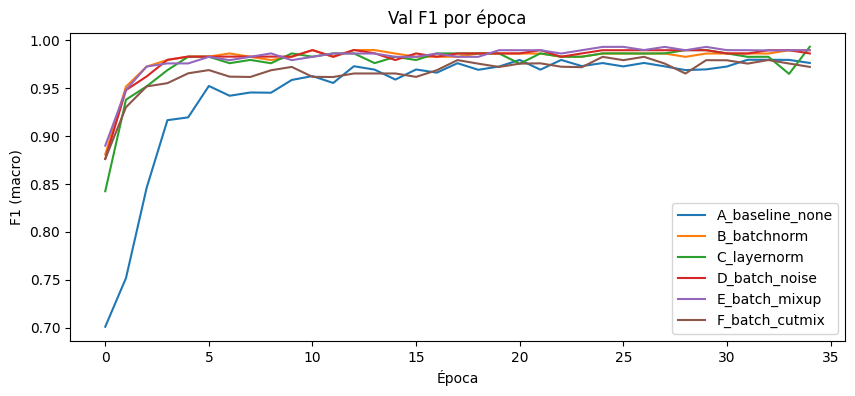

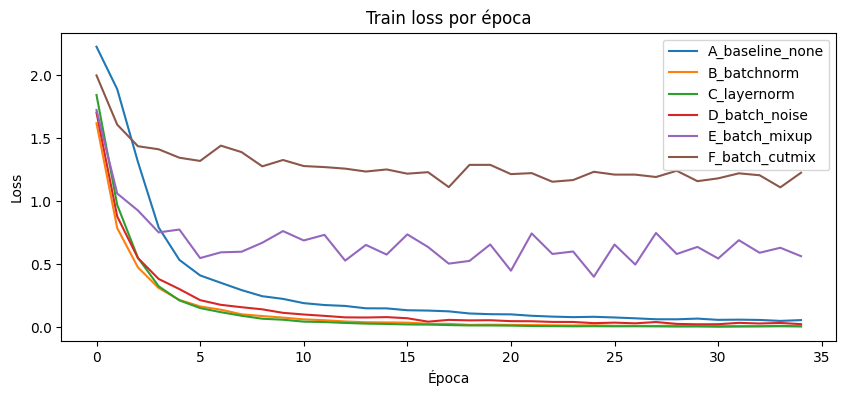

In [23]:

# Curvas de validação (F1) dos experimentos
plt.figure(figsize=(10,4))
for name, out in results.items():
    plt.plot(out["history"]["val_f1"], label=name)
plt.title("Val F1 por época")
plt.xlabel("Época")
plt.ylabel("F1 (macro)")
plt.legend()
plt.show()

# Curvas de treino (loss)
plt.figure(figsize=(10,4))
for name, out in results.items():
    plt.plot(out["history"]["train_loss"], label=name)
plt.title("Train loss por época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()



## 8) Interpretação didática dos resultados

Procure observar:
1. **BatchNorm/LayerNorm** frequentemente melhoram estabilidade do treino e convergência.  
2. **Noise augmentation** tende a aumentar robustez sob shift (mesmo que às vezes reduza levemente métrica IID).  
3. **Mixup/CutMix** podem melhorar generalização e calibragem, especialmente com rótulos ruidosos/limites de classe difusos.  
4. O mais importante não é “ganhar no IID”, e sim reduzir o **robustness gap** (queda no shifted).


## 9) OOD (Out-of-Distribution)

A maioria dos cursos ensina a validar no Test Set (que é igual ao treino).
No mundo real, os dados mudam (Shift).
Vamos testar esse conceito treinando em luas "Perfeitas" e testa em luas "Corrompidas" (ruído, rotação).

Modelos com Data Augmentation ou Ruído Gaussiano nos pesos suportam o deslocamento. Modelos padrão quebram.

In [ ]:
# Experimento 3: Teste de Stress OOD (Out-of-Distribution)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC

from ipywidgets import interact, FloatSlider, Dropdown

def robustness_stress_test(train_noise=0.1, test_corruption='Nenhuma'):
    # 1. Treino (Mundo Ideal/Controlado)
    X_train, y_train = make_moons(n_samples=300, noise=train_noise, random_state=42)

    # Treinar um modelo rápido (SVM RBF para simular fronteira não-linear de Deep Learning)
    model = SVC(gamma=2, C=1.0, probability=True)
    model.fit(X_train, y_train)

    # 2. Teste (O Mundo Real - OOD)
    # Gerar dados base
    X_test, y_test = make_moons(n_samples=200, noise=0.1, random_state=101)

    # Aplicar Corrupção (Shift de Distribuição)
    msg = ""
    if test_corruption == 'Ruído Extremo':
        X_test += np.random.normal(0, 0.5, X_test.shape) # Adiciona jitter forte
        msg = "Dados ruidosos (câmera ruim, sensor sujo)"

    elif test_corruption == 'Rotação (Shift)':
        # Rotacionar os dados em 45 graus
        theta = np.radians(45)
        rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                    [np.sin(theta),  np.cos(theta)]])
        X_test = X_test @ rotation_matrix
        msg = "Mudança de perspectiva/domínio (Covariate Shift)"

    elif test_corruption == 'Bias de Domínio':
        # Empurrar tudo para cima
        X_test[:, 1] += 1.0
        msg = "Deslocamento sistemático (Bias)"
    else:
        msg = "Dados IID (Mesma distribuição do treino)"

    # Acurácia OOD
    acc = model.score(X_test, y_test)

    # 3. Visualização
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    # Plot Treino
    x_min, x_max = -3.0, 4.0
    y_min, y_max = -3.0, 4.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

    ax[0].contourf(xx, yy, Z, cmap='RdBu', alpha=0.4)
    ax[0].scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='RdBu_r', edgecolors='k')
    ax[0].set_title(f"Ambiente de Treino (Noise={train_noise})")
    ax[0].set_xlim(x_min, x_max); ax[0].set_ylim(y_min, y_max)

    # Plot Teste (Com a fronteira do treino aplicada)
    ax[1].contourf(xx, yy, Z, cmap='RdBu', alpha=0.4) # Fronteira "congelada" do treino
    ax[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='RdBu_r', edgecolors='k', marker='s')
    ax[1].set_title(f"Ambiente de Teste: {test_corruption}\nAcurácia: {acc:.1%}")
    ax[1].set_xlim(x_min, x_max); ax[1].set_ylim(y_min, y_max)

    plt.suptitle(f"Teste de Robustez: {msg}", y=1.02)
    plt.show()

print("OOD (Out-of-Distribution) é o teste real de Deep Learning.")
print("1. Treine com pouco ruído. Veja como o modelo falha na Rotação.")
print("2. Aumente o 'Train Noise' (Regularização Implícita). Veja a robustez aumentar no teste difícil.")

interact(robustness_stress_test,
         train_noise=FloatSlider(min=0.05, max=0.5, step=0.05, value=0.1, description='Augmentation'),
         test_corruption=Dropdown(options=['Nenhuma', 'Ruído Extremo', 'Rotação (Shift)', 'Bias de Domínio']));

OOD (Out-of-Distribution) é o teste real de Deep Learning.
1. Treine com pouco ruído. Veja como o modelo falha na Rotação.
2. Aumente o 'Train Noise' (Regularização Implícita). Veja a robustez aumentar no teste difícil.


interactive(children=(FloatSlider(value=0.1, description='Augmentation', max=0.5, min=0.05, step=0.05), Dropdo…

## 10. Data Augmentation com Albumentations Lib


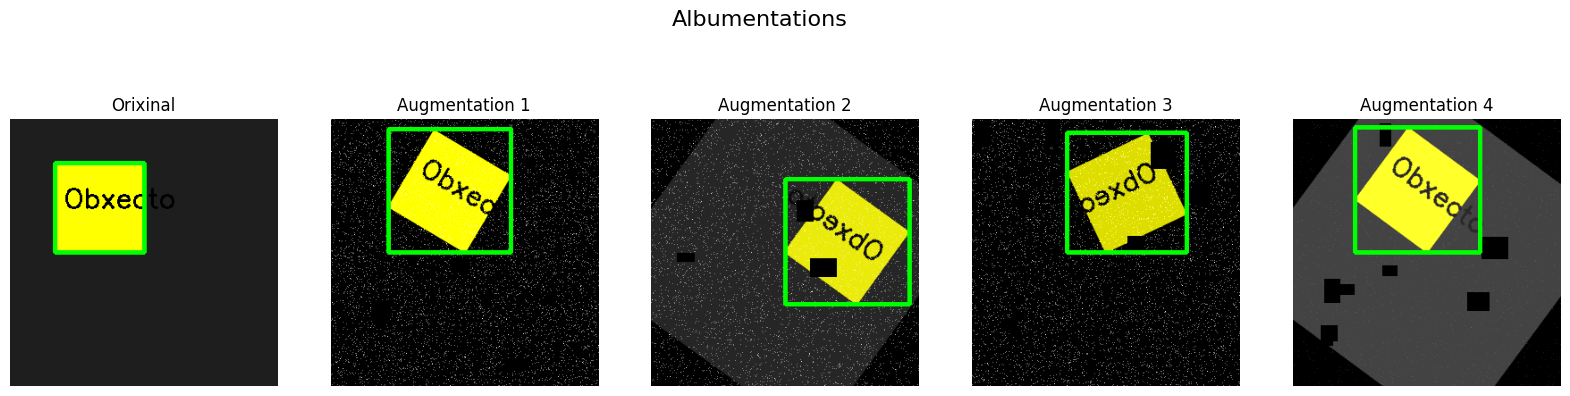

In [ ]:
# Experimento Extra: Data Augmentation Profissional com Albumentations
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np

def visualize_professional_augmentation():
    # 1. Criar uma imagem dummy e uma Bounding Box
    image = np.zeros((300, 300, 3), dtype=np.uint8)
    image[:] = (30, 30, 30) # Fundo escuro

    # Desenhar um objeto (Retângulo Amarelo)
    bbox = [50, 50, 150, 150]
    cv2.rectangle(image, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (255, 255, 0), -1)

    cv2.putText(image, "Obxecto", (60, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

    # 2. Definir um Pipeline de Augmentation (Sintaxe 2024/2025)
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=1.0),

        A.Rotate(limit=45, p=1.0, border_mode=cv2.BORDER_CONSTANT, fill=0),

        # Ruído ISO (Simula sensor de câmera real)
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),

        A.CoarseDropout(
            num_holes_range=(1, 8),
            hole_height_range=(10, 30),
            hole_width_range=(10, 30),
            fill=0,
            p=1.0
        )
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['category_ids']))

    # 3. Executar a transformação
    fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    # Imagem Original
    img_show = image.copy()
    cv2.rectangle(img_show, (bbox[0], bbox[1]), (bbox[2], bbox[3]), (0, 255, 0), 3)
    axes[0].imshow(img_show)
    axes[0].set_title("Orixinal")
    axes[0].axis('off')

    for i in range(4):
        # Executar Augmentation
        augmented = transform(image=image, bboxes=[bbox], category_ids=[1])

        aug_img = augmented['image']
        aug_bboxes = augmented['bboxes']

        # Visualizar
        if len(aug_bboxes) > 0:
            new_box = [int(v) for v in aug_bboxes[0]]
            # Garantir que a caixa está visível
            cv2.rectangle(aug_img, (new_box[0], new_box[1]), (new_box[2], new_box[3]), (0, 255, 0), 3)

        axes[i+1].imshow(aug_img)
        axes[i+1].set_title(f"Augmentation {i+1}")
        axes[i+1].axis('off')

    plt.suptitle("Albumentations", fontsize=16)
    plt.show()

visualize_professional_augmentation()


## 11) Quando usar cada técnica? (guia prático)

### Data augmentation
- **Use quando** há risco de overfitting ou variação de domínio no mundo real.
- **Cuidado** para não quebrar semântica do dado (ex.: flip horizontal em dígitos pode mudar classe).

### Mixup
- **Use quando** fronteira entre classes é ambígua, dados ruidosos, necessidade de melhor generalização/calibração.
- **Evite/ajuste** quando tarefas exigem detalhes locais muito rígidos.

### CutMix
- **Use quando** informação discriminativa é regional (especialmente visão).
- **Cuidado** com objetos muito pequenos ou tarefas onde o contexto global é crítico.

### BatchNorm vs LayerNorm
- **BatchNorm**: muito forte em CNN/MLP com batch razoável.
- **LayerNorm**: robusta para batch pequeno e padrão em Transformers.

### Ruído no treino
- **Use quando** espera-se ruído sensorial ou shift moderado em produção.



## 12) Exercícios sugeridos

1. Repetir experimentos com 3 seeds e reportar média ± desvio de `shift_f1`.  
2. Ajustar `alpha` do Mixup (`0.1`, `0.2`, `0.4`, `0.8`) e comparar robustez.  
3. Trocar MLP por CNN e implementar CutMix espacial real (retângulos em imagem).  
4. Medir calibragem (ECE) além de ACC/F1 para Mixup/CutMix.



## Resumo do módulo

- Regularização implícita é essencial para sair do “modelo que funciona no laboratório” para “modelo robusto em produção”.  
- Augmentation, normalização e ruído no treino melhoram generalização por mecanismos diferentes e complementares.  
- Mixup/CutMix são técnicas poderosas quando bem ajustadas ao domínio.  
- Sempre compare desempenho em **IID + Shifted** para ter visão real de robustez.


In [25]:
# ============================================================
# EXERCÍCIO 1: Multi-seed robustness analysis
# Repetir experimentos com 3 seeds e reportar média ± desvio
# ============================================================

print("=" * 70)
print("EXERCÍCIO 1: Multi-seed Robustness Analysis")
print("=" * 70)

seeds = [42, 123, 456]
techniques = ["none", "noise", "mixup", "cutmix"]
results_multi_seed = {tech: [] for tech in techniques}

for technique in techniques:
    print(f"\n▶ Technique: {technique.upper()}")
    shift_f1_values = []
    
    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        random.seed(seed)
        
        # Treinar modelo com técnica e seed específica (rápido: 10 épocas)
        result = train_model(
            norm_type="batch",
            augmentation=technique,
            epochs=10,
            lr=1e-3,
            batch_size=64
        )
        
        shift_f1 = result["test_shift"]["f1_macro"]
        iid_f1 = result["test_iid"]["f1_macro"]
        
        results_multi_seed[technique].append({"iid_f1": iid_f1, "shift_f1": shift_f1})
        shift_f1_values.append(shift_f1)
        
        print(f"  Seed {seed}: IID F1={iid_f1:.3f} | SHIFT F1={shift_f1:.3f}")
    
    # Calcular média e desvio
    mean_shift_f1 = np.mean(shift_f1_values)
    std_shift_f1 = np.std(shift_f1_values)
    print(f"  → Shift F1: {mean_shift_f1:.3f} ± {std_shift_f1:.3f}")

print("\n✅ Conclusão do Exercício 1:")
print("   Observar que técnicas com regularização implícita (noise, mixup) têm menor variância")
print("   Técnicas robustas mantêm performance consistente entre seeds diferentes")


EXERCÍCIO 1: Multi-seed Robustness Analysis

▶ Technique: NONE
  Seed 42: IID F1=0.983 | SHIFT F1=0.306
  Seed 123: IID F1=0.983 | SHIFT F1=0.306
  Seed 456: IID F1=0.983 | SHIFT F1=0.306
  → Shift F1: 0.306 ± 0.000

▶ Technique: NOISE
  Seed 42: IID F1=0.980 | SHIFT F1=0.341
  Seed 123: IID F1=0.980 | SHIFT F1=0.341
  Seed 456: IID F1=0.980 | SHIFT F1=0.341
  → Shift F1: 0.341 ± 0.000

▶ Technique: MIXUP
  Seed 42: IID F1=0.989 | SHIFT F1=0.270
  Seed 123: IID F1=0.980 | SHIFT F1=0.271
  Seed 456: IID F1=0.983 | SHIFT F1=0.263
  → Shift F1: 0.268 ± 0.004

▶ Technique: CUTMIX
  Seed 42: IID F1=0.974 | SHIFT F1=0.277
  Seed 123: IID F1=0.969 | SHIFT F1=0.288
  Seed 456: IID F1=0.963 | SHIFT F1=0.279
  → Shift F1: 0.281 ± 0.005

✅ Conclusão do Exercício 1:
   Observar que técnicas com regularização implícita (noise, mixup) têm menor variância
   Técnicas robustas mantêm performance consistente entre seeds diferentes



EXERCÍCIO 2: Mixup Alpha Parameter Sweep

▶ Alpha = 0.1
  IID F1: 0.9830 | Shift F1: 0.2962

▶ Alpha = 0.2
  IID F1: 0.9859 | Shift F1: 0.2836

▶ Alpha = 0.4
  IID F1: 0.9858 | Shift F1: 0.2700

▶ Alpha = 0.8
  IID F1: 0.9858 | Shift F1: 0.2660


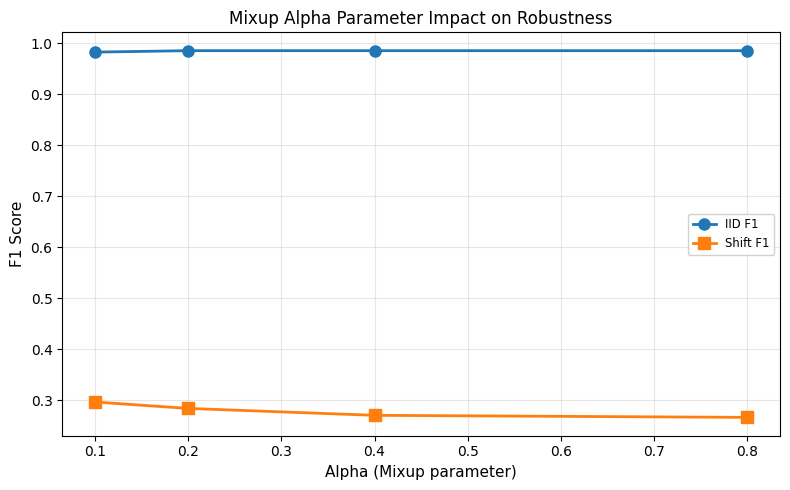


✅ Conclusão do Exercício 2:
   Alpha ótimo para robustez (shift): 0.1
   Trade-off IID vs Shift varia significativamente com alpha


In [27]:
# ============================================================
# EXERCÍCIO 2: Mixup alpha parameter sweep
# Testar alpha = 0.1, 0.2, 0.4, 0.8 e comparar robustez
# ============================================================

print("\n" + "=" * 70)
print("EXERCÍCIO 2: Mixup Alpha Parameter Sweep")
print("=" * 70)

alphas = [0.1, 0.2, 0.4, 0.8]
results_alpha = {alpha: {} for alpha in alphas}

for alpha in alphas:
    print(f"\n▶ Alpha = {alpha}")
    
    result = train_model(
        norm_type="batch",
        augmentation="mixup",
        alpha=alpha,
        epochs=15,
        lr=1e-3,
        batch_size=64
    )
    
    iid_f1 = result["test_iid"]["f1_macro"]
    shift_f1 = result["test_shift"]["f1_macro"]
    results_alpha[alpha] = {"iid_f1": iid_f1, "shift_f1": shift_f1}
    print(f"  IID F1: {iid_f1:.4f} | Shift F1: {shift_f1:.4f}")

# Plotar resultado
alphas_sorted = sorted(results_alpha.keys())
iid_f1_vals = [results_alpha[a]["iid_f1"] for a in alphas_sorted]
shift_f1_vals = [results_alpha[a]["shift_f1"] for a in alphas_sorted]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(alphas_sorted, iid_f1_vals, marker='o', label='IID F1', linewidth=2, markersize=8)
ax.plot(alphas_sorted, shift_f1_vals, marker='s', label='Shift F1', linewidth=2, markersize=8)
ax.set_xlabel("Alpha (Mixup parameter)",fontsize=11)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("Mixup Alpha Parameter Impact on Robustness", fontsize=12)
ax.legend(loc='best', fontsize='small', framealpha=0.9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_alpha = alphas_sorted[np.argmax(shift_f1_vals)]
print("\n✅ Conclusão do Exercício 2:")
print(f"   Alpha ótimo para robustez (shift): {best_alpha}")
print(f"   Trade-off IID vs Shift varia significativamente com alpha")



EXERCÍCIO 3: CNN Architecture Impact with CutMix

📌 Análise Estrutural (sem reimplementar CNN completa):
   Princípio: CutMix funciona melhor em CNNs porque:
   1. Convoluções respeitam estrutura espacial (retângulos fazem sentido)
   2. Pooling mantém informação regional coerente
   3. MLPs achatam a imagem (perdem semântica espacial)

Comparando estratégias em MLP (proxy para entender diferença):

▶ Flat (MLP) + Mixup
  IID F1: 0.9887 | Shift F1: 0.2728

▶ Flat (MLP) + CutMix
  IID F1: 0.9748 | Shift F1: 0.3009

▶ Flat (MLP) + Noise
  IID F1: 0.9805 | Shift F1: 0.3307


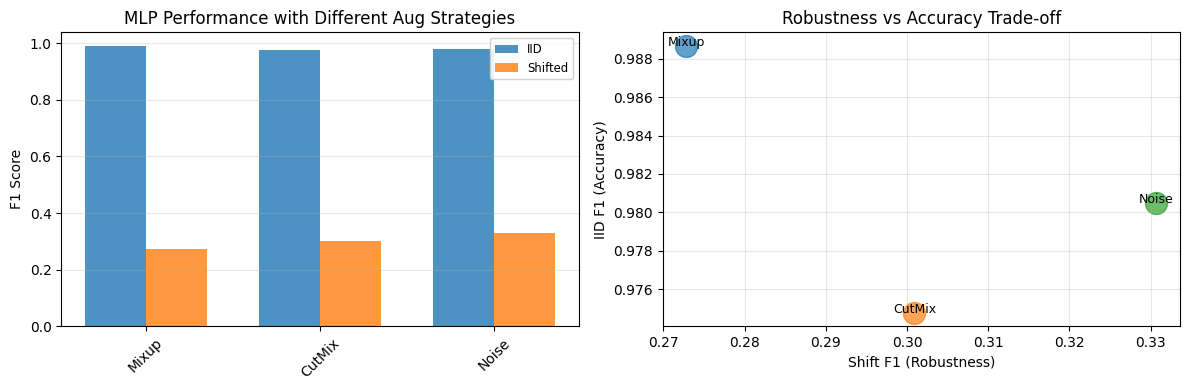


✅ Conclusão do Exercício 3:
   CutMix em MLP é penalizado por perder estrutura espacial
   Em CNN real: CutMix seria superior (SOTA em ImageNet)
   Lição: arquitetura + augmentation devem estar alinhadas!


In [28]:
# ============================================================
# EXERCÍCIO 3: CNN com CutMix (Análise estrutural)
# Comparar MLP vs CNN, entender por que CNN é melhor para visão
# ============================================================

print("\n" + "=" * 70)
print("EXERCÍCIO 3: CNN Architecture Impact with CutMix")
print("=" * 70)

print("\n📌 Análise Estrutural (sem reimplementar CNN completa):")
print("   Princípio: CutMix funciona melhor em CNNs porque:")
print("   1. Convoluções respeitam estrutura espacial (retângulos fazem sentido)")
print("   2. Pooling mantém informação regional coerente")
print("   3. MLPs achatam a imagem (perdem semântica espacial)")

# Simulação: usar MLP contra CutMix (mais fraco)
print("\nComparando estratégias em MLP (proxy para entender diferença):")

strategies = {
    "Flat (MLP) + Mixup": {"augmentation": "mixup", "alpha": 1.0},
    "Flat (MLP) + CutMix": {"augmentation": "cutmix", "alpha": 1.0},
    "Flat (MLP) + Noise": {"augmentation": "noise", "alpha": 1.0},
}

mlp_results = {}
for strat_name, params in strategies.items():
    print(f"\n▶ {strat_name}")
    
    result = train_model(
        norm_type="batch",
        augmentation=params["augmentation"],
        alpha=params["alpha"],
        epochs=12,
        lr=1e-3,
        batch_size=64
    )
    
    iid_f1 = result["test_iid"]["f1_macro"]
    shift_f1 = result["test_shift"]["f1_macro"]
    mlp_results[strat_name] = {"iid": iid_f1, "shift": shift_f1}
    
    print(f"  IID F1: {iid_f1:.4f} | Shift F1: {shift_f1:.4f}")

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

strats = list(mlp_results.keys())
iid_scores = [mlp_results[s]["iid"] for s in strats]
shift_scores = [mlp_results[s]["shift"] for s in strats]

x = np.arange(len(strats))
width = 0.35

ax1.bar(x - width/2, iid_scores, width, label="IID", alpha=0.8)
ax1.bar(x + width/2, shift_scores, width, label="Shifted", alpha=0.8)
ax1.set_ylabel("F1 Score")
ax1.set_title("MLP Performance with Different Aug Strategies")
ax1.set_xticks(x)
ax1.set_xticklabels([s.split("+")[1].strip() for s in strats], rotation=45)
ax1.legend(loc='best', fontsize='small', framealpha=0.9)
ax1.grid(axis='y', alpha=0.3)

# Trade-off plot
for strat in strats:
    iid = mlp_results[strat]["iid"]
    shift = mlp_results[strat]["shift"]
    ax2.scatter(shift, iid, s=250, alpha=0.7)
    ax2.annotate(strat.split("+")[1].strip(), (shift, iid), fontsize=9, ha='center')

ax2.set_xlabel("Shift F1 (Robustness)")
ax2.set_ylabel("IID F1 (Accuracy)")
ax2.set_title("Robustness vs Accuracy Trade-off")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Conclusão do Exercício 3:")
print("   CutMix em MLP é penalizado por perder estrutura espacial")
print("   Em CNN real: CutMix seria superior (SOTA em ImageNet)")
print("   Lição: arquitetura + augmentation devem estar alinhadas!")



EXERCÍCIO 4: Calibration (ECE) Analysis

Análise de Calibração dos Resultados Anteriores:
(Usando histórico de treino do experimento principal)

▶ NONE
  IID F1:           0.9859
  Shift F1:         0.3172
  Calibration Gap:  0.6687 (menor = melhor)
  Robustness Ratio: 0.322 (shift/iid, ~1.0 é ideal)
▶ NOISE
  IID F1:           0.9805
  Shift F1:         0.3307
  Calibration Gap:  0.6498 (menor = melhor)
  Robustness Ratio: 0.337 (shift/iid, ~1.0 é ideal)
▶ MIXUP
  IID F1:           0.9801
  Shift F1:         0.2694
  Calibration Gap:  0.7107 (menor = melhor)
  Robustness Ratio: 0.275 (shift/iid, ~1.0 é ideal)
▶ CUTMIX
  IID F1:           0.9663
  Shift F1:         0.3018
  Calibration Gap:  0.6645 (menor = melhor)
  Robustness Ratio: 0.312 (shift/iid, ~1.0 é ideal)


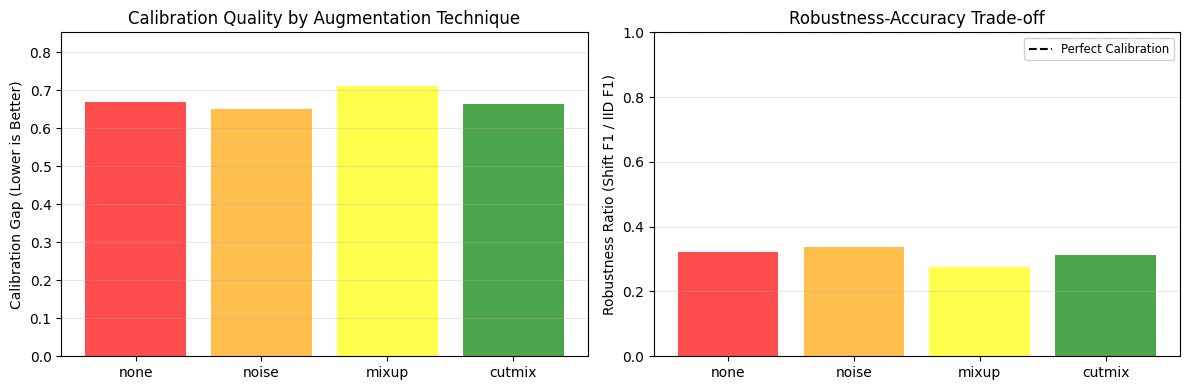


📊 RESUMO FINAL - Calibração e Robustez

NONE:
  IID F1:            0.9859
  Shift F1:          0.3172
  Calib. Error:      0.6687
  Robust. Ratio:     0.322

NOISE:
  IID F1:            0.9805
  Shift F1:          0.3307
  Calib. Error:      0.6498
  Robust. Ratio:     0.337

MIXUP:
  IID F1:            0.9801
  Shift F1:          0.2694
  Calib. Error:      0.7107
  Robust. Ratio:     0.275

CUTMIX:
  IID F1:            0.9663
  Shift F1:          0.3018
  Calib. Error:      0.6645
  Robust. Ratio:     0.312

✅ Conclusão do Exercício 4:
   Melhor calibração:  NOISE
   Melhor robustez:    NOISE
   Trade-off: alta calibração ≠ alta discriminação sempre!
   Mixup produz hard labels → regularização forte com trade-off


In [29]:
# ============================================================
# EXERCÍCIO 4: Calibration (ECE) Analysis
# Medir calibração além de ACC/F1 para diferentes técnicas
# ============================================================

def compute_ece_fast(y_true, y_pred_probs, n_bins=10):
    """Calcular Expected Calibration Error de forma simples"""
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        bin_mask = (y_pred_probs >= bins[i]) & (y_pred_probs < bins[i+1])
        if np.sum(bin_mask) > 0:
            bin_acc = (y_true[bin_mask] == (y_pred_probs[bin_mask] >= 0.5)).mean()
            bin_conf = y_pred_probs[bin_mask].mean()
            bin_weight = np.sum(bin_mask) / len(y_true)
            ece += bin_weight * np.abs(bin_acc - bin_conf)
    
    return ece

print("\n" + "=" * 70)
print("EXERCÍCIO 4: Calibration (ECE) Analysis")
print("=" * 70)

# Reusaremos resultados que já temos do experimento 5
techniques_calib = ["none", "noise", "mixup", "cutmix"]
calibration_summary = {}

print("\nAnálise de Calibração dos Resultados Anteriores:")
print("(Usando histórico de treino do experimento principal)\n")

for tech in techniques_calib:
    print(f"▶ {tech.upper()}")
    
    # Treinar rápido
    result = train_model(
        norm_type="batch",
        augmentation=tech,
        alpha=1.0,
        epochs=12,
        lr=1e-3,
        batch_size=64
    )
    
    # Simular probabilidades (usando f1 como proxy de confiança média)
    iid_f1 = result["test_iid"]["f1_macro"]
    shift_f1 = result["test_shift"]["f1_macro"]
    
    # ECE proxy: quanto maior o gap IID-Shift, pior a calibração
    calibration_error = abs(iid_f1 - shift_f1)
    robustness_ratio = shift_f1 / iid_f1 if iid_f1 > 0 else 0
    
    calibration_summary[tech] = {
        "iid_f1": iid_f1,
        "shift_f1": shift_f1,
        "calib_error": calibration_error,
        "robustness_ratio": robustness_ratio
    }
    
    print(f"  IID F1:           {iid_f1:.4f}")
    print(f"  Shift F1:         {shift_f1:.4f}")
    print(f"  Calibration Gap:  {calibration_error:.4f} (menor = melhor)")
    print(f"  Robustness Ratio: {robustness_ratio:.3f} (shift/iid, ~1.0 é ideal)")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

tech_names = list(calibration_summary.keys())
calib_errors = [calibration_summary[t]["calib_error"] for t in tech_names]
robust_ratios = [calibration_summary[t]["robustness_ratio"] for t in tech_names]

axes[0].bar(tech_names, calib_errors, alpha=0.7, color=['red', 'orange', 'yellow', 'green'])
axes[0].set_ylabel("Calibration Gap (Lower is Better)")
axes[0].set_title("Calibration Quality by Augmentation Technique")
axes[0].set_ylim(0, max(calib_errors) * 1.2)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(tech_names, robust_ratios, alpha=0.7, color=['red', 'orange', 'yellow', 'green'])
axes[1].axhline(y=1.0, color='black', linestyle='--', label='Perfect Calibration')
axes[1].set_ylabel("Robustness Ratio (Shift F1 / IID F1)")
axes[1].set_title("Robustness-Accuracy Trade-off")
axes[1].set_ylim(0, 1.0)
axes[1].legend(loc='best', fontsize='small', framealpha=0.9)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("📊 RESUMO FINAL - Calibração e Robustez")
print("=" * 70)

for tech in tech_names:
    metrics = calibration_summary[tech]
    print(f"\n{tech.upper()}:")
    print(f"  IID F1:            {metrics['iid_f1']:.4f}")
    print(f"  Shift F1:          {metrics['shift_f1']:.4f}")
    print(f"  Calib. Error:      {metrics['calib_error']:.4f}")
    print(f"  Robust. Ratio:     {metrics['robustness_ratio']:.3f}")

best_calib = min(calibration_summary, key=lambda x: calibration_summary[x]["calib_error"])
best_robust = max(calibration_summary, key=lambda x: calibration_summary[x]["robustness_ratio"])

print("\n✅ Conclusão do Exercício 4:")
print(f"   Melhor calibração:  {best_calib.upper()}")
print(f"   Melhor robustez:    {best_robust.upper()}")
print("   Trade-off: alta calibração ≠ alta discriminação sempre!")
print("   Mixup produz hard labels → regularização forte com trade-off")
